In [7]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv('abalone_sea_snails_csv.csv')
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [9]:
#Here 'Rings'=>Age, which has continuous value, hence a supervise learning Regression base problem statement

# About Dataset
########## The Abalone dataset is a popular machine learning dataset that contains measurements of physical characteristics of abalone, a type of sea snail. The dataset is often used as a benchmark for regression tasks in machine learning.

In [10]:
"""
Sex: categorical variable (M for male, F for female, and I for infant)
Length: continuous variable representing the longest shell measurement in mm
Diameter: continuous variable representing the diameter of the shell in mm
Height: continuous variable representing the height of the shell in mm
Whole weight: continuous variable representing the weight of the whole abalone in grams
Shucked weight: continuous variable representing the weight of the meat in grams
Viscera weight: continuous variable representing the weight of the gut (after bleeding) in grams
Shell weight: continuous variable representing the weight of the shell in grams
Rings: integer variable representing the age of the abalone (the number of rings on the shell)

"""

'\nSex: categorical variable (M for male, F for female, and I for infant)\nLength: continuous variable representing the longest shell measurement in mm\nDiameter: continuous variable representing the diameter of the shell in mm\nHeight: continuous variable representing the height of the shell in mm\nWhole weight: continuous variable representing the weight of the whole abalone in grams\nShucked weight: continuous variable representing the weight of the meat in grams\nViscera weight: continuous variable representing the weight of the gut (after bleeding) in grams\nShell weight: continuous variable representing the weight of the shell in grams\nRings: integer variable representing the age of the abalone (the number of rings on the shell)\n\n'

In [11]:
df.shape

(4176, 9)

In [12]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

In [13]:
#To check the duplicate value
df.duplicated().sum()

0

In [14]:
#basic statistic of dataset
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4176.000000,4176.000000,4176.000000,4176.000000,4176.000000,4176.000000,4176.000000,4176.000000
mean,0.523968,0.407863,0.139514,0.828679,0.359326,0.180574,0.238817,9.933669
std,0.120097,0.099245,0.041832,0.490430,0.221974,0.109620,0.139217,3.224555
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093375,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.170750,0.233750,9.000000
75%,0.615000,0.480000,0.165000,1.153250,0.501625,0.252625,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [15]:
#To check the column datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4176 entries, 0 to 4175
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4176 non-null   object 
 1   Length          4176 non-null   float64
 2   Diameter        4176 non-null   float64
 3   Height          4176 non-null   float64
 4   Whole weight    4176 non-null   float64
 5   Shucked weight  4176 non-null   float64
 6   Viscera weight  4176 non-null   float64
 7   Shell weight    4176 non-null   float64
 8   Rings           4176 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [16]:
#To check the correlation
corr = df.corr()

<AxesSubplot:>

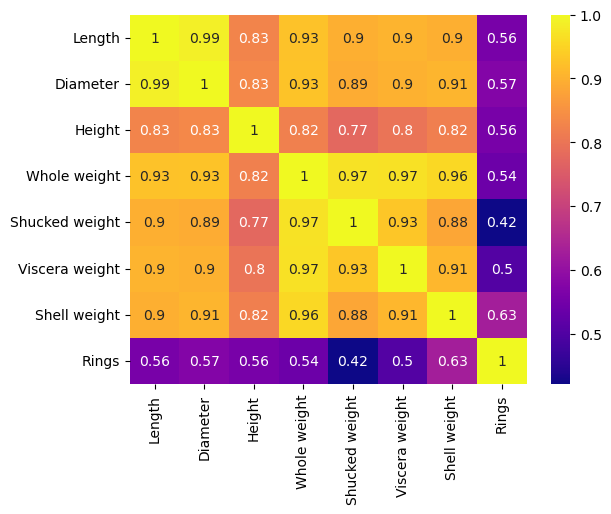

In [17]:
import seaborn as sns
sns.heatmap(corr,annot=True,cbar=True,cmap="plasma")

In [19]:
#To check the label in dataset
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [20]:
#We notics here Sex column having label datatype value
df['Sex'].value_counts()

M    1528
I    1342
F    1306
Name: Sex, dtype: int64

<AxesSubplot:xlabel='Sex', ylabel='Count'>

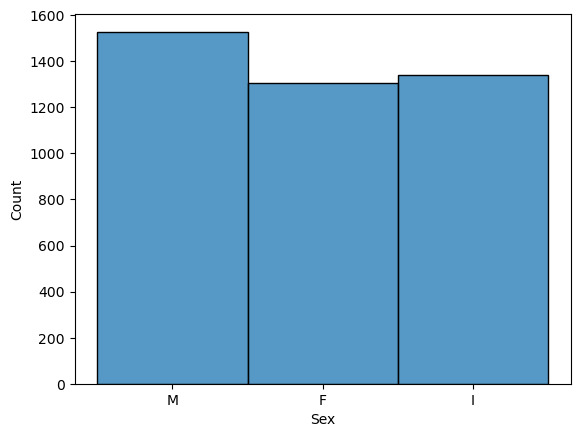

In [21]:
#Check EDA: Exploratory data analysis
sns.histplot(df['Sex'],bins=20)

In [22]:
#convert lable 'Sex' column into numerical column
df['Sex'] = df['Sex'].map({"M":0,"F":1,'I':2})

In [23]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [24]:
df['Sex'].value_counts()

0    1528
2    1342
1    1306
Name: Sex, dtype: int64

<AxesSubplot:xlabel='Rings', ylabel='Count'>

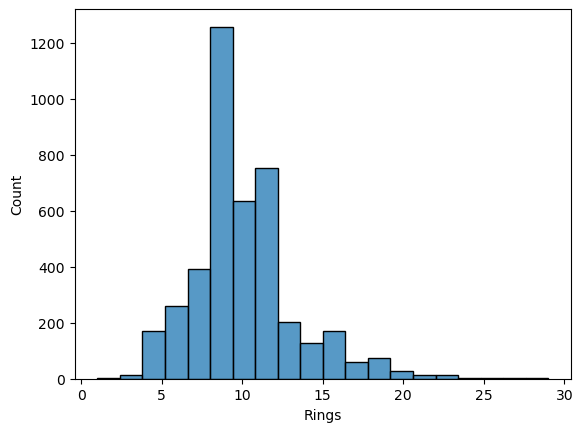

In [25]:
#EDA For Output(Rings)
sns.histplot(df['Rings'],bins=20)

<AxesSubplot:xlabel='Length', ylabel='Rings'>

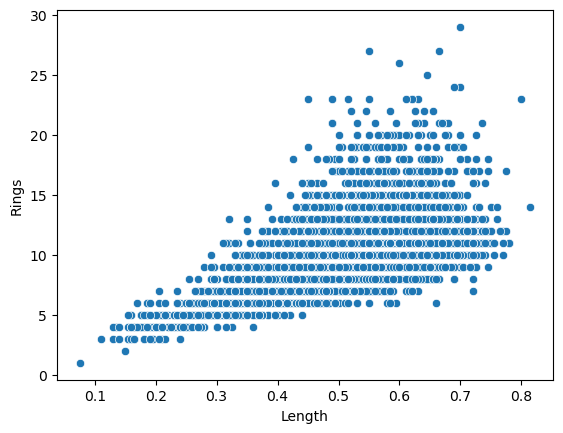

In [26]:
#To check EDA with respect to length and rings
sns.scatterplot(x='Length',y='Rings',data=df)

In [27]:
#Split into X and y axis
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [29]:
# X
y

0       15
1        7
2        9
3       10
4        7
        ..
4171     8
4172    11
4173    10
4174     9
4175    12
Name: Rings, Length: 4176, dtype: int64

In [30]:
X.shape

(4176, 8)

In [31]:
y.shape

(4176,)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [34]:
X_train.shape

(2797, 8)

In [35]:
X_test.shape

(1379, 8)

## Scale the dataset to avoid dominance of the feature using StandardScaler

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [37]:
X_test_scale

array([[-1.15499969,  0.66142805,  0.46037495, ...,  0.25959316,
         1.09294356,  0.59591144],
       [-1.15499969,  0.53596082,  0.30878345, ...,  0.10788264,
         0.30129361,  0.02728522],
       [ 0.05675355,  0.28502637,  0.35931395, ..., -0.25800742,
         0.38823783,  0.66698972],
       ...,
       [ 1.26850679, -0.30048735, -0.34811305, ..., -0.37402134,
        -0.61390864, -0.79011498],
       [ 0.05675355, -0.67688903, -0.75235705, ..., -0.71537   ,
        -0.66424476, -0.86474718],
       [ 1.26850679, -1.47151479, -1.45978404, ..., -1.29320857,
        -1.21794213, -1.28766293]])

In [38]:
X_test_scale

array([[-1.15499969,  0.66142805,  0.46037495, ...,  0.25959316,
         1.09294356,  0.59591144],
       [-1.15499969,  0.53596082,  0.30878345, ...,  0.10788264,
         0.30129361,  0.02728522],
       [ 0.05675355,  0.28502637,  0.35931395, ..., -0.25800742,
         0.38823783,  0.66698972],
       ...,
       [ 1.26850679, -0.30048735, -0.34811305, ..., -0.37402134,
        -0.61390864, -0.79011498],
       [ 0.05675355, -0.67688903, -0.75235705, ..., -0.71537   ,
        -0.66424476, -0.86474718],
       [ 1.26850679, -1.47151479, -1.45978404, ..., -1.29320857,
        -1.21794213, -1.28766293]])

# Train the Model

In [39]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score,mean_squared_error

In [42]:
#Cobimation of model for training/Hybrid model
models = {
    ('lr', LinearRegression()),
    ('ridge', Ridge()),
    ('lass',Lasso()),
    ('dtr',DecisionTreeRegressor()),
    ('rfr',RandomForestRegressor())
}
for name,model in models:
    model.fit(X_train_scale,y_train)
    y_pred = model.predict(X_test)
    
    print(f"{name}: wit MSE: {mean_squared_error(y_test,y_pred)} and r2 sore: {r2_score(y_test,y_pred)}")

C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


lass: wit MSE: 9.766037251294355 and r2 sore: 0.036715812957807126
lr: wit MSE: 13.761687853396822 and r2 sore: -0.3573997267346918
rfr: wit MSE: 13.257984554024654 and r2 sore: -0.3077163791535753
ridge: wit MSE: 12.993122387514273 and r2 sore: -0.2815913982447249
dtr: wit MSE: 25.709209572153735 and r2 sore: -1.5358571142995765


C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


In [43]:
#Select the one which MSE error is less and r2_score is high, hence LinearRegression

In [44]:
lr = LinearRegression()
lr.fit(X_train_scale,y_train)
y_pred = lr.predict(X_test)
y_pred

C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([13.99043302, 13.00675838, 13.7398439 , ..., 11.19215063,
       11.28123741, 10.34936091])

In [45]:
def predicted_age(Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight):
    features= np.array([[Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight]])
    pred = lr.predict(features).reshape(1,-1)
    return pred[0]

Sex = 2
Length = 8.0
Diameter = 4.0
Height = 6.0
Whole_weight = 10.0
Shucked_weight = 20.0
Viscera_weight = 20.0
Shell_weight = 15.0
prediction = predicted_age(Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight)
prediction

array([-36.7102649])

In [46]:
lass = Lasso()
lass.fit(X_train_scale,y_train)
y_pred = lass.predict(X_test)
y_pred

C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


array([10.32496708, 10.24259901, 10.33526309, ..., 10.12419491,
       10.1133841 , 10.05212285])

In [48]:
def predicted_age(Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight):
    features= np.array([[Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight]])
    pred = lass.predict(features).reshape(1,-1)
    return pred[0]

Sex = 2
Length = 8.0
Diameter = 4.0
Height = 6.0
Whole_weight = 10.0
Shucked_weight = 20.0
Viscera_weight = 20.0
Shell_weight = 15.0
prediction = predicted_age(Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight)
prediction

array([25.43435961])

# Save the Model

In [50]:
import pickle
pickle.dump(lass,open("model.pkl",'wb'))